In [2]:
%pip install pandas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [5]:
df=pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [7]:
df.shape

(440, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [9]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [10]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [15]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='str')

In [17]:
X = df.drop(['Channel', 'Region'], axis=1)
X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [18]:
X.shape

(440, 6)

<Figure size 1500x1000 with 0 Axes>

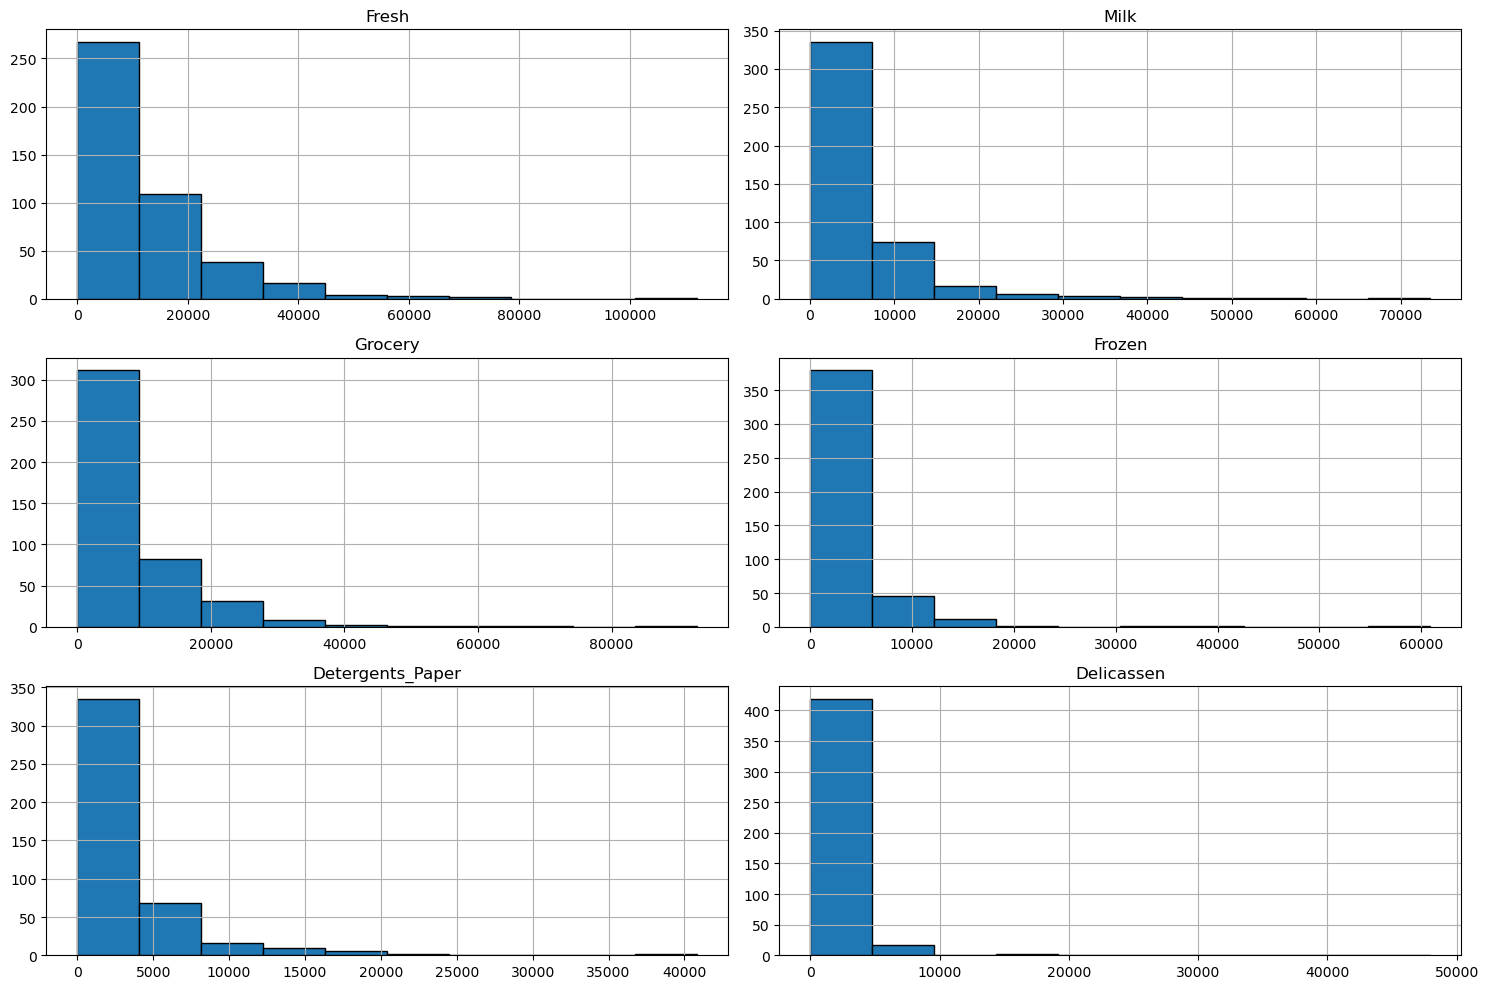

In [19]:
plt.figure(figsize=(15,10))
X.hist(figsize=(15,10), edgecolor='black')
plt.tight_layout()
plt.show()

<ipython-input-20-9afafeca9e5a>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X.values, labels=X.columns)


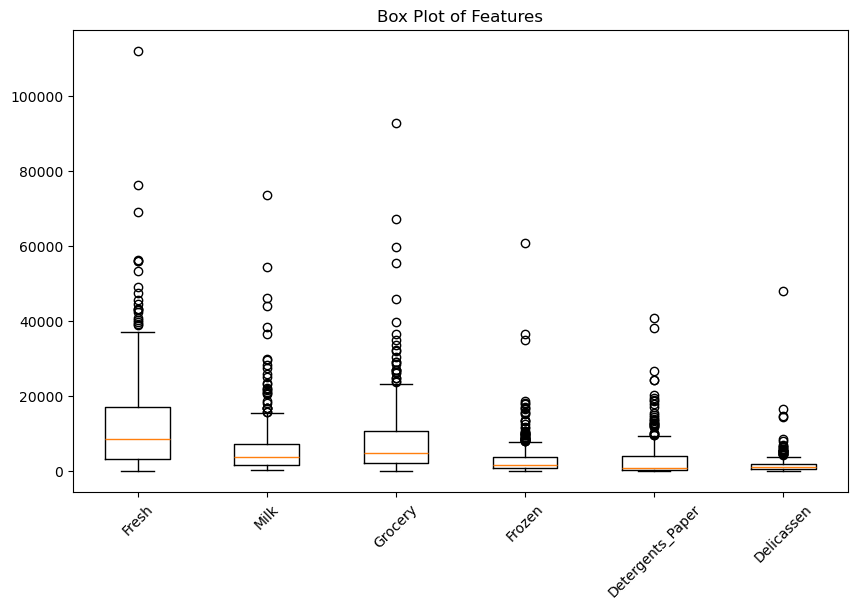

In [20]:
plt.figure(figsize=(10,6))
plt.boxplot(X.values, labels=X.columns)
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()

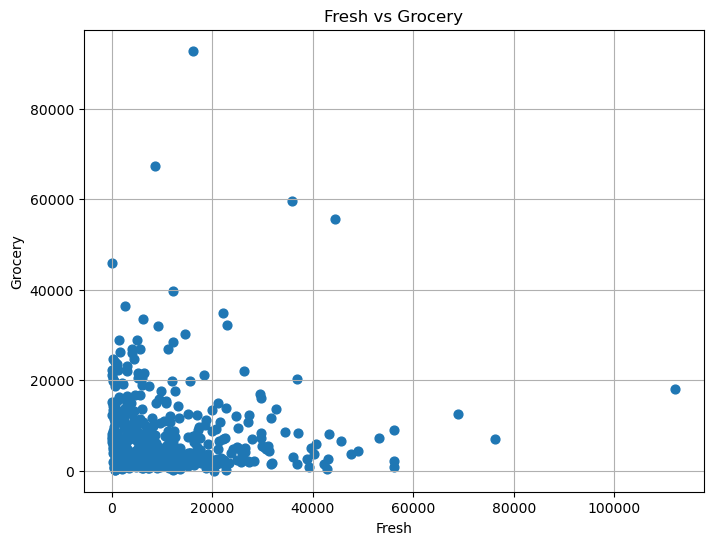

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(
    X['Fresh'],
    X['Grocery'],
    s=40
)
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("Fresh vs Grocery")
plt.grid()
plt.show()

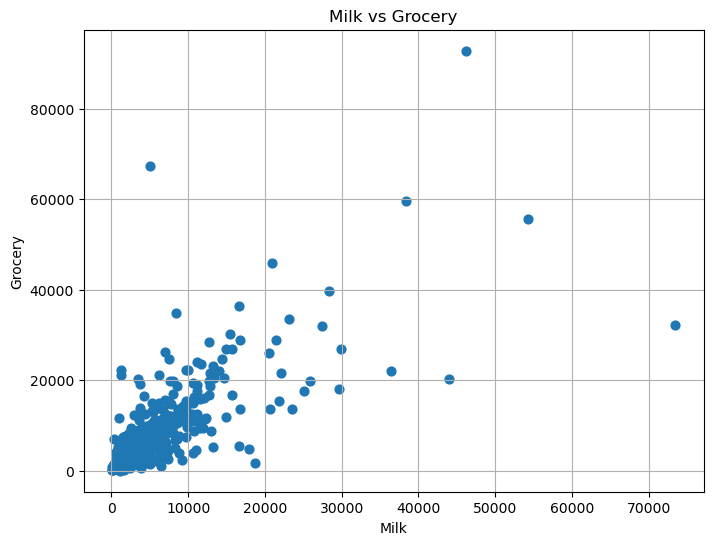

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(
    X['Milk'],
    X['Grocery'],
    s=40
)
plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("Milk vs Grocery")
plt.grid()
plt.show()

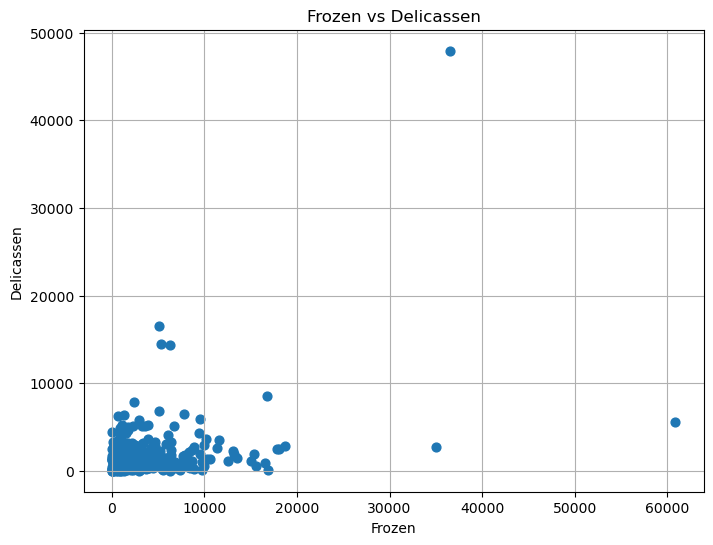

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(
    X['Frozen'],
    X['Delicassen'],
    s=40
)
plt.xlabel("Frozen")
plt.ylabel("Delicassen")
plt.title("Frozen vs Delicassen")
plt.grid()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


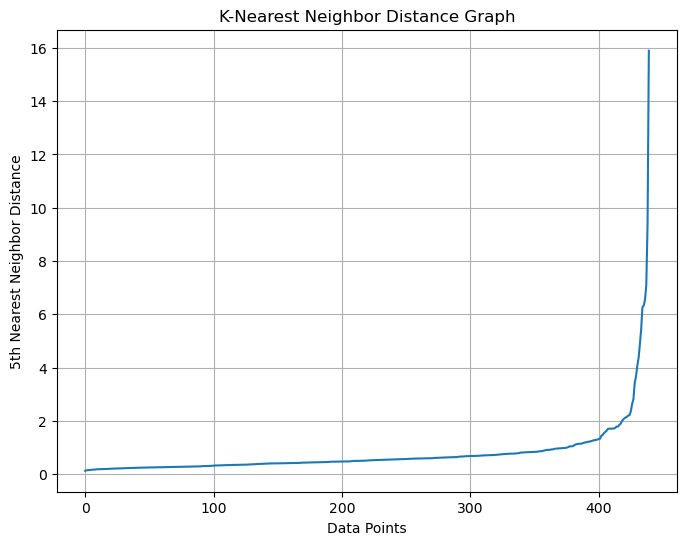

In [25]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("K-Nearest Neighbor Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid()
plt.show()

In [26]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)
clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [27]:
df["Cluster"] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


In [28]:
print("Unique Cluster Labels:")
print(np.unique(clusters))

Unique Cluster Labels:
[-1  0]


In [29]:
print(df["Cluster"].value_counts().sort_index())

Cluster
-1     27
 0    413
Name: count, dtype: int64


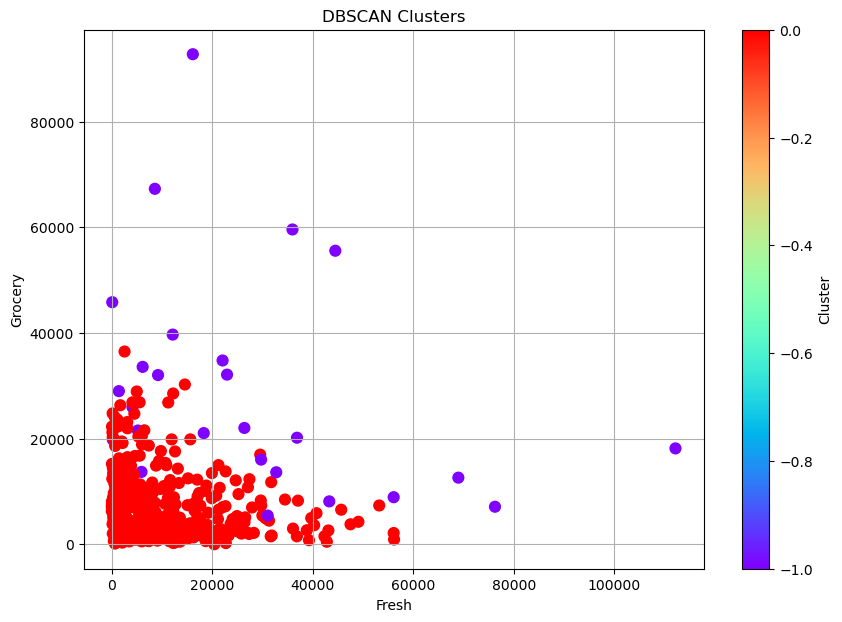

In [30]:
plt.figure(figsize=(10,7))
plt.scatter(
    df["Fresh"],
    df["Grocery"],
    c=df["Cluster"],
    cmap="rainbow",
    s=60
)
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("DBSCAN Clusters")
plt.colorbar(label="Cluster")
plt.grid()
plt.show()

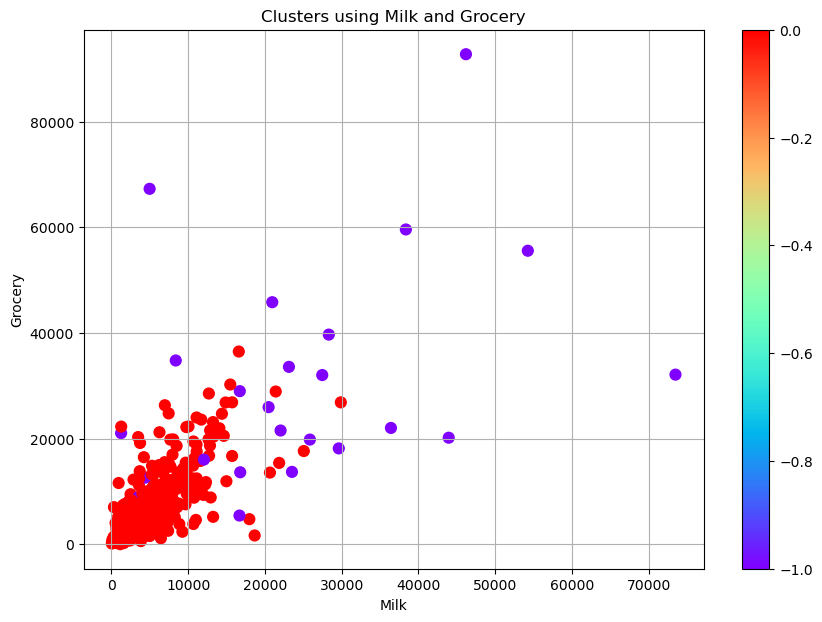

In [31]:
plt.figure(figsize=(10,7))
plt.scatter(
    df["Milk"],
    df["Grocery"],
    c=df["Cluster"],
    cmap="rainbow",
    s=60
)
plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("Clusters using Milk and Grocery")
plt.colorbar()
plt.grid()
plt.show()

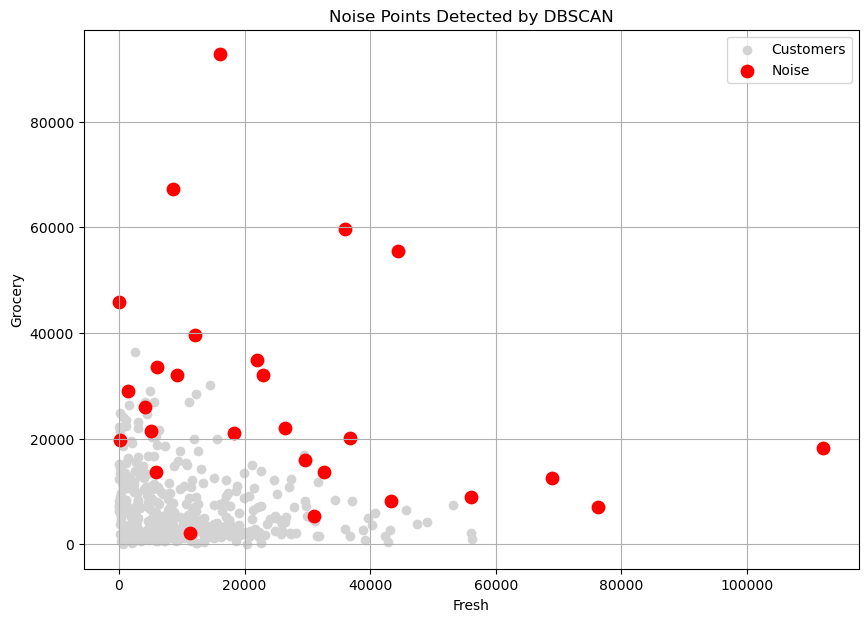

In [32]:
noise = df[df["Cluster"] == -1]
plt.figure(figsize=(10,7))
plt.scatter(
    df["Fresh"],
    df["Grocery"],
    color="lightgray",
    label="Customers")
plt.scatter(
    noise["Fresh"],
    noise["Grocery"],
    color="red",
    label="Noise",
    s=80
)
plt.xlabel("Fresh")
plt.ylabel("Grocery")
plt.title("Noise Points Detected by DBSCAN")
plt.legend()
plt.grid()
plt.show()

In [33]:
noise_points = (clusters == -1).sum()
print("Number of Noise Points :", noise_points)

Number of Noise Points : 27


In [35]:
from sklearn.metrics import silhouette_score
import numpy as np
# Remove noise points
mask = clusters != -1
# Remaining cluster labels
cluster_labels = clusters[mask]
# Count unique clusters
n_clusters = len(np.unique(cluster_labels))
if n_clusters >= 2:
    score = silhouette_score(X_scaled[mask], cluster_labels)
    print("Silhouette Score:", round(score, 4))
else:
    print("Silhouette Score cannot be calculated because DBSCAN found only", n_clusters, "cluster.")

Silhouette Score cannot be calculated because DBSCAN found only 1 cluster.


Conclusion

• Data was standardized before clustering.
• DBSCAN automatically identified the optimal clusters.
• Noise points (outliers) were detected successfully.
• Silhouette Score indicates the quality of clustering.
• DBSCAN performed well for datasets with arbitrary-shaped clusters and outliers.